# 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [1]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集1中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [16]:
iris = datasets.load_iris() # load_iris()=>載入iris資料集，載入後，iris不是dataFrame,而是一個Bunch物件
print(iris.DESCR) # DESCR是Description的縮寫

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

In [17]:
print(iris.keys()) #key():value()。key()是目綠

print(iris.data[0:10]) #取出資料前10筆，data[start:end]

print(type(iris.data)) #查看資料型態，結果顯示'numpy.ndarray'是多維陣列的意思，n-dimensional array

print(iris.target_names) #查看每朵花的分類標籤名稱(Label)

print(iris.target) #查看每朵花的分類標籤(Label)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
<class 'numpy.ndarray'>
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [18]:
iris.feature_names[:2]

['sepal length (cm)', 'sepal width (cm)']

In [19]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [20]:
iris.data.shape #顯示出資料共150筆，4個特徵，也就是150列，4欄

(150, 4)

In [21]:
# we only take the first two features.
X = iris.data[:,:2]
print(X.shape)

(150, 2)


In [22]:
#以下是組成 pandas DataFrame (也可以不用這種做)
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
x.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [24]:
iris["target"].shape

(150,)

In [23]:
#建立Target欄位與資料
#把 Iris 資料集中的 target（標籤資料） 轉成 Pandas DataFrame
#ML常用 x=特徵資料，y=分類標籤
y = pd.DataFrame(iris["target"], columns=["target"]) # columns=[""]設定欄位名稱
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [15]:
print(iris.data.size) #計算資料的總元素數量
print("target_names: ",iris.target_names)

600
target_names:  ['setosa' 'versicolor' 'virginica']


In [29]:
iris_data = pd.concat([x,y],axis=1)
iris_data = iris_data[['sepal length (cm)','sepal width (cm)','target']]
iris_data.head(10)

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
5,5.4,3.9,0
6,4.6,3.4,0
7,5.0,3.4,0
8,4.4,2.9,0
9,4.9,3.1,0


In [25]:
#合併資料特徵欄位與目標欄位
iris_data = pd.concat([x,y],axis=1)
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [30]:
#只選擇目標為0與1的資料
iris_data = iris_data[iris_data['target'].isin([0,1])] #取出taget欄位，再用isin[值]判斷[值]是否存在於指定清單中
iris_data

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
...,...,...,...
95,5.7,3.0,1
96,5.7,2.9,1
97,6.2,2.9,1
98,5.1,2.5,1


## 切分訓練集與測試集
> train_test_split()

In [33]:
from sklearn.model_selection import train_test_split #自動將資料隨機切分成訓練集(Train Set)、測試集(Test Set)

X_train, X_test, Y_train, Y_test = train_test_split(iris_data[['sepal length (cm)','sepal width (cm)']],iris_data['target'],test_size=0.3)
# iris_data[['sepal length (cm)', 'sepal width (cm)']]=>取出兩個特徵欄位，這些是x，作為ML的輸入特徵
# iris_data['target']=>這是y，代表正確答案Label
# test_size=0.3，表示30%當測試資料，70%當訓練資料


In [39]:
X_train.shape

(70, 2)

In [40]:
X_train.head()

,sepal length (cm),sepal width (cm)
22,4.6,3.6
20,5.4,3.4
31,5.4,3.4
38,4.4,3.0
76,6.8,2.8


In [41]:
X_test.shape

(30, 2)

In [35]:
X_test.head()

,sepal length (cm),sepal width (cm)
54,6.5,2.8
81,5.5,2.4
44,5.1,3.8
78,6.0,2.9
14,5.8,4.0


In [42]:
Y_train.head()

22    0
20    0
31    0
38    0
76    1
Name: target, dtype: int64

In [43]:
Y_test.head()

54    1
81    1
44    0
78    1
14    0
Name: target, dtype: int64

# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [44]:
from IPython.display import Math # 從 IPython 的 display 模組匯入 Math
Math(r'x^{(i)}_{norm}=\frac{x^{(i)}-x_{min}}{x_{max}-x_{min}}') # Math(r'x^2')=>顯示x2，r'...'稱為raw string(原始字串)，保留\
# {norm}表示下標Xnorm
# \frac{A}{B}表示A/B
# 稱為Min-Max Normalization正規化

<IPython.core.display.Math object>

In [45]:
Math(r'x^{(i)}_{std}=\frac{x^{(i)}-\mu_{x}}{\sigma_{x}}')

<IPython.core.display.Math object>

In [56]:
def norm_stats(dfs): # 改成Pandas寫法
    minimum = dfs.min()
    maximum = dfs.max()
    mu = dfs.mean()
    sigma = dfs.std()
    return (minimum, maximum, mu, sigma)


def z_score(col, stats):
    minimum, maximum, mu, sigma = stats
    df = pd.DataFrame()
    for c in col.columns:
        df[c] = (col[c]-mu[c])/sigma[c]
    return df

In [59]:
stats = norm_stats(X_train)
arr_x_train = np.array(z_score(X_train, stats))
arr_x_train[:5]

# arr_y_train = np.array(Y_train)

array([[-1.32562307,  1.19786256],
       [-0.12246437,  0.75066054],
       [-0.12246437,  0.75066054],
       [-1.62641274, -0.14374351],
       [ 1.98306336, -0.59094553]])

## use sklearn

In [60]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

[5.48142857 3.06428571]
[0.66014995 0.44401921]


In [61]:
#transform: (x-u)/std.
X_train_std = sc.transform(X_train)
X_train_std[:5]

array([[-1.33519448,  1.2065115 ],
       [-0.1233486 ,  0.75608054],
       [-0.1233486 ,  0.75608054],
       [-1.63815595, -0.14478138],
       [ 1.99738169, -0.59521234]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [62]:
X_test_std = sc.transform(X_test)
print(X_test_std[:10])

[[ 1.54293949 -0.59521234]
 [ 0.02813214 -1.49607426]
 [-0.5777908   1.65694246]
 [ 0.78553581 -0.36999686]
 [ 0.48257434  2.10737342]
 [ 1.84590096  0.0804341 ]
 [ 0.02813214  2.55780438]
 [ 0.02813214  0.98129602]
 [-0.5777908   1.65694246]
 [-0.5777908   0.98129602]]


you can also use fit_transform method (i.e., fit and then transform)    

In [63]:
X_train_std = sc.fit_transform(X_train)  
X_test_std = sc.fit_transform(X_test)
print(X_test_std[:10])


[[ 1.80338978 -0.70940312]
 [ 0.09131087 -1.45614325]
 [-0.59352069  1.1574472 ]
 [ 0.94735033 -0.52271809]
 [ 0.60493455  1.53081726]
 [ 2.14580556 -0.14934803]
 [ 0.09131087  1.90418732]
 [ 0.09131087  0.5973921 ]
 [-0.59352069  1.1574472 ]
 [-0.59352069  0.5973921 ]]


In [64]:
print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: 0.0
std of X_train_std: 0.9999999999999999


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


49.5756712112146
30.751910471872357


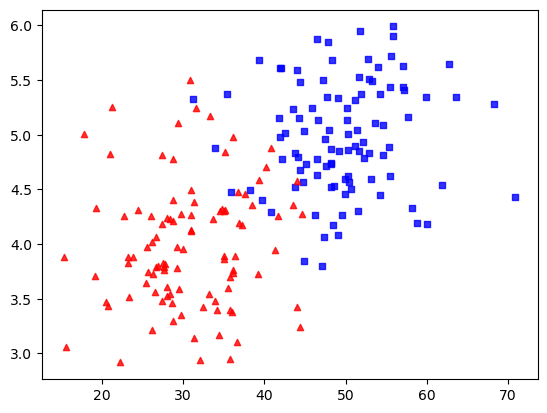

In [65]:
x1 = np.random.normal(50, 6, 100)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5, 100)

x2 = np.random.normal(30,6,100)
y2 = np.random.normal(4,0.5,100)
plt.scatter(x1,y1,c='b',marker='s',s=20,alpha=0.8)
plt.scatter(x2,y2,c='r', marker='^', s=20, alpha=0.8)

print(np.sum(x1)/len(x1))
print(np.sum(x2)/len(x2))

In [66]:
x_val = np.concatenate((x1,x2))
y_val = np.concatenate((y1,y2))

x_val.shape

(200,)

In [67]:
def minmax_norm(X):
    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [68]:
minmax_norm(x_val[:10])

array([0.43901666, 1.        , 0.18816075, 0.49565046, 0.7509198 ,
       0.37951499, 0.        , 0.37937227, 0.32184682, 0.58059562])

In [69]:
from sklearn.preprocessing import MinMaxScaler
x_val=x_val.reshape(-1, 1)
scaler = MinMaxScaler().fit(x_val)  # default range 0~1
print(scaler.data_max_)
print(scaler.transform(x_val)[:10])

[70.89285063]
[[0.65168566]
 [0.86764634]
 [0.55511414]
 [0.67348786]
 [0.77175841]
 [0.62877941]
 [0.48267825]
 [0.62872447]
 [0.60657901]
 [0.70618904]]
